# Simple LangGraph research-to-weights walkthrough

One hypothesis, one observation cutoff, one LLM call, and a Black-Litterman allocation. **No backtest.** The research subgraph feeds a deterministic BL node that reuses the application's recipe runner and displays Portfolio Allocation: Prior vs Black-Litterman.

Select the repository `.venv` kernel and install the backend requirements. Set `OPENAI_API_KEY` in your environment or local `.env`, never in notebook cells. Only the **Invoke the graph** cell makes the model call. Rerun from setup after changing the graph or calibration.

EPS and rates are synthetic. Observation-date filtering is not a publication-time firewall. Research strength is translated into annual return targets using the explicit illustrative MAX_ANNUAL_ALPHA setting, not an empirically calibrated forecast.

## 1. Imports and research inputs

Edit `HYPOTHESIS`, `UNIVERSE`, and `AS_OF`. A single date replaces the monthly rebalance loop.

In [14]:
import sys
from datetime import date
from pathlib import Path
from typing import TypedDict

for parent in [Path.cwd(), *Path.cwd().parents]:
    candidates = [parent, parent / 'backend']
    backend = next((p for p in candidates if (p / 'app' / 'services' / 'bl_backtest').is_dir()), None)
    if backend is not None:
        break
else:
    raise RuntimeError('Open this notebook from inside the repository.')

if str(backend) not in sys.path:
    sys.path.insert(0, str(backend))

import pandas as pd
from dotenv import load_dotenv
from IPython.display import display
from langgraph.graph import START, END, StateGraph

from app.services.bl_backtest.data_interface.load import load_research_data
from app.services.bl_backtest.data_interface.process import prepare_context
from app.services.bl_backtest.research_graph import build_research_graph
from app.services.bl_backtest.research_bl import generate_bl_allocation
from app.services.bl_backtest.schema import ResearchContext, ResearchRequest, ResearchResult

load_dotenv(backend / '.env')
load_dotenv(backend.parent / '.env')

HYPOTHESIS = (
    'Use earnings estimate revisions as the primary signal. Favor securities '
    'whose estimates improved over the last 63 observations, and reduce conviction '
    'when 21-observation revisions disagree. Use rates and recent price returns '
    'as secondary context, not as proof of causality. Stay neutral when evidence '
    'is weak or EPS is not applicable.'
)
UNIVERSE = ['AAPL', 'MSFT', 'JPM', 'BND']
AS_OF = date(2021, 9, 30)
MAX_ANNUAL_ALPHA = 0.05  # Illustrative annual return adjustment of at most 5 percentage points.


## 2. Prepare evidence deterministically

Read the existing CSVs, select the securities and cutoff, and calculate the features in Python. Only this compact context enters the graph. BND has no applicable EPS, so its empty estimates are preserved rather than filled with zeros.

In [15]:
request = ResearchRequest(hypothesis=HYPOTHESIS, universe=UNIVERSE, as_of=AS_OF)
data = load_research_data()
context = prepare_context(data, request)

print('Requested cutoff:', request.as_of)
print('Selected observation date:', context.observation_date)
for warning in context.warnings:
    print('WARNING:', warning)

evidence_table = pd.DataFrame([
    {'reference': reference, **entry.model_dump()}
    for reference, entry in context.evidence.items()
])
display(evidence_table)


Requested cutoff: 2021-09-30
Selected observation date: 2021-09-30


,reference,asset,metric,value,unit,status,source,columns,start,end,observations,synthetic
0,AAPL.eps_latest,AAPL,eps_latest,6.459115,USD,available,eps_estimates_revisions.csv,[eps_estimate_usd],2021-09-30,2021-09-30,1,True
1,AAPL.price_latest,AAPL,price_latest,138.261307,USD,available,market_prices.csv,[AAPL],2021-09-30,2021-09-30,1,False
2,AAPL.eps_change_21,AAPL,eps_change_21,-0.038557,fraction,available,eps_estimates_revisions.csv,[eps_estimate_usd],2021-08-31,2021-09-30,22,True
3,AAPL.return_21,AAPL,return_21,-0.068037,fraction,available,market_prices.csv + market_returns.csv,[AAPL],2021-08-31,2021-09-30,22,False
4,AAPL.eps_change_63,AAPL,eps_change_63,-0.017620,fraction,available,eps_estimates_revisions.csv,[eps_estimate_usd],2021-07-01,2021-09-30,64,True
5,AAPL.return_63,AAPL,return_63,0.032359,fraction,available,market_prices.csv + market_returns.csv,[AAPL],2021-07-01,2021-09-30,64,False
6,MSFT.eps_latest,MSFT,eps_latest,9.158859,USD,available,eps_estimates_revisions.csv,[eps_estimate_usd],2021-09-30,2021-09-30,1,True
7,MSFT.price_latest,MSFT,price_latest,271.662781,USD,available,market_prices.csv,[MSFT],2021-09-30,2021-09-30,1,False
8,MSFT.eps_change_21,MSFT,eps_change_21,-0.010066,fraction,available,eps_estimates_revisions.csv,[eps_estimate_usd],2021-08-31,2021-09-30,22,True
9,MSFT.return_21,MSFT,return_21,-0.066119,fraction,available,market_prices.csv + market_returns.csv,[MSFT],2021-08-31,2021-09-30,22,False


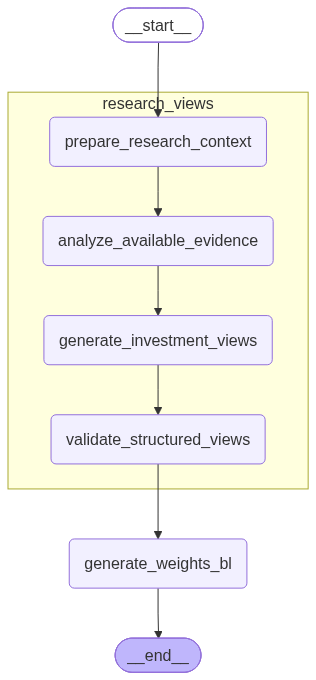

In [16]:
from IPython.display import Image, display
class NotebookState(TypedDict, total=False):
    context: ResearchContext
    result: ResearchResult
    stages: list[str]
    weights: dict[str, float]
    bl_result: dict


def generate_weights_bl(state: NotebookState):
    views_df = pd.DataFrame([view.model_dump() for view in state['result'].views.views])
    bl_result = generate_bl_allocation(
        views_df, state['result'].context, data, max_annual_alpha=MAX_ANNUAL_ALPHA,
    )
    return {
        'weights': bl_result['weights'],
        'bl_result': bl_result,
        'stages': [*state['stages'], 'generate_weights_bl'],
    }


research_graph = build_research_graph()
builder = StateGraph(NotebookState)
builder.add_node('research_views', research_graph)
builder.add_node('generate_weights_bl', generate_weights_bl)
builder.add_edge(START, 'research_views')
builder.add_edge('research_views', 'generate_weights_bl')
builder.add_edge('generate_weights_bl', END)
workflow = builder.compile()
display(Image(workflow.get_graph(xray=True).draw_mermaid_png()))


## 4. Print the actual graph

`xray=True` expands the research subgraph so all four internal stages are visible. Both the connections and Mermaid diagram come from the compiled graph, not a hand-drawn approximation. This cell makes no model call and uses no external image-rendering service.

## 5. Invoke the graph and inspect views

**Executing this cell makes one paid model call**, followed by deterministic BL optimization using the configured research model and registry defaults. Invalid responses or fabricated citations stop execution rather than producing fallback weights. The updated BL path has not been executed in this notebook.

In [17]:
final_state = workflow.invoke({'context': context})
research_result = final_state['result']

print('Completed stages:', ' -> '.join(final_state['stages']))
print('Research result views:')
print(pd.DataFrame([view.model_dump() for view in research_result.views.views]))


RUNNING BLACK-LITTERMAN RECIPE: research_views_bl
Description: Research strength mapped to explicit annual prior-relative alpha targets.

📦 Universe: 4 assets - AAPL, MSFT, JPM, BND
⚙️  Parameters: tau=0.05, risk_aversion=1.0, rf=0.02, cov_lookback_years=5

📊 BOTTOM-UP VIEWS

  View 1 (Absolute): Apple's 63-observation EPS estimate revision is negative (-1.76%), indicating a decline in earnings expectations over the longer term. The 21-observation revision is also negative (-3.86%), which aligns with the longer-term trend, supporting a negative view. The recent 63-day price return is slightly positive (+3.24%), but the 21-day return is negative (-6.80%), reflecting some short-term weakness. Given the primary signal is EPS revisions, which are negative and consistent, the view is negative with moderate strength and confidence.
    AAPL → 0.37% (confidence: 0.80)

  View 2 (Absolute): Microsoft's 63-observation EPS estimate revision is positive (+0.89%), indicating improving earnings ex

## 6. Final weights

The last graph node executes the same BL recipe runner used by the application. Display its allocation next to the market-cap prior, using the application's ticker/priorWeight/blWeight shape. This cell makes no additional LLM call.

In [ ]:
weights = final_state['weights']
print('Final long-only Black-Litterman weights:')
for asset, weight in weights.items():
    print(f'  {asset}: {weight:.2%}')
print(f'Total: {sum(weights.values()):.2%}')

allocation = pd.DataFrame(final_state['bl_result']['allocation'])
display(allocation)
display(pd.DataFrame(final_state['bl_result']['recipe']['bottom_up_views']))
print(final_state['bl_result']['calibration'])

import plotly.graph_objects as go
fig = go.Figure()
fig.add_bar(x=allocation['ticker'], y=100 * allocation['priorWeight'], name='Prior Weight', marker_color='#f59e0b')
fig.add_bar(x=allocation['ticker'], y=100 * allocation['blWeight'], name='BL Weight', marker_color='#60a5fa')
fig.update_layout(title='Portfolio Allocation: Prior vs Black-Litterman', barmode='group', yaxis_title='Weight (%)', template='plotly_dark')
fig.show()
